In [150]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.signal import savgol_filter
import matplotlib.pyplot as plt
import pickle
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

import sys
import os
# onep is installed via `pip install -e .` -- no sys.path shim needed
import onep

In [91]:
# Load the pickle file
with open('/Users/ryansenne/Desktop/Dill/collection_fc_allmice.pkl', 'rb') as file:
    collection_fc = pickle.load(file)

# Define animals for each group
mouse_ids = ['astroM3', 
             'astroM4', 
             'astroM5', 
             'astroM6', 
             'astroM6', 
             'astroM7', 
             'astroM8', 
             'astroM9']

#Grab your mice and take accepted traces - convert to numpy arrays within mouse_id variable names
for mouse_id in mouse_ids:
    try:
        traces = collection_fc.animals[mouse_id].accepted_traces.to_numpy()
        globals()[mouse_id] = traces[:3303, :]
        print(f"Created variable {mouse_id} with shape {globals()[mouse_id].shape}")
    except Exception as e:
        print(f"Error loading {mouse_id}: {e}")


calcium_times = pd.read_csv(r"C:\Users\ryansenne\Desktop\Dill\Time.csv").to_numpy().squeeze()

Created variable astroM3 with shape (3303, 165)
Created variable astroM4 with shape (3303, 275)
Created variable astroM5 with shape (3303, 288)
Created variable astroM6 with shape (3303, 177)
Created variable astroM6 with shape (3303, 177)
Created variable astroM7 with shape (3303, 253)
Created variable astroM8 with shape (3303, 239)
Created variable astroM9 with shape (3303, 115)


In [33]:
ddir = Path(r"C:\Users\ryansenne\Desktop\Dill\dlc")

dlc_data = {}
# open all dlc files in the directory and put them in dictionary
for file in ddir.glob("*.csv"):
    animal_id = file.stem
    dlc_data[animal_id] = pd.read_csv(file, header=[0, 1, 2], index_col=0)

In [48]:
df = dlc_data['Astro_3_FC_VideoDLC_resnet50_OLMMay26shuffle1_300000']
df.columns.names

FrozenList(['scorer', 'bodyparts', 'coords'])

In [95]:
camera_fps = 15.0
multiplicative_factor = 1 / camera_fps

# add time column to each dlc dataframe
for animal_id, df in dlc_data.items():
    num_frames = df.shape[0]
    time_column = np.arange(num_frames) * multiplicative_factor
    df[('time', '', '')] = time_column

In [ ]:
def extract_velocity_dlc(df, bodypart='tail_base', fps=15.0,
                         likelihood_thresh=0.9,
                         max_gap_frames=30, 
                         smooth=True, scorer=None):

    if scorer is None:
        scorer = df.columns.get_level_values('scorer')[0]

    x = df[(scorer, bodypart, 'x')].astype(float).to_numpy()
    y = df[(scorer, bodypart, 'y')].astype(float).to_numpy()

    # mask low-confidence
    if (scorer, bodypart, 'likelihood') in df.columns:
        p = df[(scorer, bodypart, 'likelihood')].astype(float).to_numpy()
        bad = p < likelihood_thresh
        x[bad] = np.nan
        y[bad] = np.nan

    # If too few valid points, bail early
    if np.isfinite(x).sum() < 5 or np.isfinite(y).sum() < 5:
        return np.full_like(x, np.nan, dtype=float)

    # interpolate short gaps only; keep long gaps as NaN
    xs = pd.Series(x).interpolate(limit=max_gap_frames, limit_direction="both")
    ys = pd.Series(y).interpolate(limit=max_gap_frames, limit_direction="both")

    # fill remaining edge NaNs using nearest valid (prevents gradient NaNs at ends)
    xs = xs.fillna(method="ffill").fillna(method="bfill")
    ys = ys.fillna(method="ffill").fillna(method="bfill")

    x = xs.to_numpy()
    y = ys.to_numpy()

    # velocity
    dx = np.gradient(x) * fps
    dy = np.gradient(y) * fps
    v = np.sqrt(dx**2 + dy**2)

    # remove any remaining non-finite
    v[~np.isfinite(v)] = np.nan
    v = pd.Series(v).fillna(method="ffill").fillna(method="bfill").to_numpy()

    # smooth
    if smooth and len(v) >= 11 and np.isfinite(v).all():
        v = savgol_filter(v, 11, 3)

    return v

def run_mouse_velocity_pca(
    mouse_id,
    dlc_df,
    calcium_data,          # shape (T_ca, n_cells)
    calcium_times,         # shape (T_ca,)
    t_shock=120.0,
    bodypart='tail_base',
    dlc_fps=15.0,
    n_pcs=10
):
    # velocity + DLC time
    v = extract_velocity_dlc(dlc_df, bodypart=bodypart, fps=dlc_fps)
    t_dlc = dlc_df.time.to_numpy()

    # ensure equal length
    L = min(len(v), len(t_dlc))
    v = v[:L]
    t_dlc = t_dlc[:L]

    # interpolate onto calcium time grid
    good = np.isfinite(v) & np.isfinite(t_dlc)
    v_on_ca = np.interp(calcium_times, t_dlc[good], v[good])

    # cut to shock time
    keep = calcium_times <= t_shock
    X = calcium_data[keep, :]
    t_ca = calcium_times[keep]
    v_keep = v_on_ca[keep]

    # 4) z-score calcium (per-cell), PCA
    Xz = (X - X.mean(0)) / (X.std(0) + 1e-8)
    pca = PCA(n_components=min(n_pcs, Xz.shape[1]))
    scores = pca.fit_transform(Xz)  # (T, n_pcs)

    #  population correlation PC1 vs velocity
    pc1 = scores[:, 0]
    v_z = (v_keep - v_keep.mean()) / (v_keep.std() + 1e-8)
    pc1_z = (pc1 - pc1.mean()) / (pc1.std() + 1e-8)
    r_pop = np.corrcoef(pc1_z, v_z)[0, 1]

    #single-cell correlations
    cell_r = np.array([np.corrcoef(Xz[:, i], v_z)[0, 1] for i in range(Xz.shape[1])])

    return {
        "mouse_id": mouse_id,
        "t": t_ca,
        "velocity": v_keep,
        "velocity_z": v_z,
        "scores": scores,
        "pca": pca,
        "pc1_z": pc1_z,
        "r_pop": r_pop,
        "cell_r": cell_r,
        "Xz": Xz,
    }

In [147]:
res = run_mouse_velocity_pca(
    mouse_id='astroM3',
    dlc_df=df,
    calcium_data=astroM3,
    calcium_times=calcium_times[:3303]
)

In [148]:
def plot_mouse_summary(res, show_cell_hist=True):
    mouse_id = res["mouse_id"]
    t = res["t"]
    v = res["velocity"]
    pc1z = res["pc1_z"]
    r = res["r_pop"]

    if show_cell_hist:
        fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    else:
        fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

    ax0 = axes[0]
    ax0.plot(t, v)
    ax0.set_ylabel("Velocity (px/s)")
    ax0.set_title(f"{mouse_id}  |  PC1–velocity r = {r:.3f}")

    ax1 = axes[1]
    ax1.plot(t, pc1z, label="PC1 (z)")
    ax1.plot(t, (v - v.mean()) / (v.std() + 1e-8), label="Velocity (z)", alpha=0.7)
    ax1.set_ylabel("z-score")
    ax1.legend(loc="upper right")

    if show_cell_hist:
        ax2 = axes[2]
        ax2.hist(res["cell_r"], bins=40)
        ax2.axvline(0, color="k")
        ax2.set_ylabel("# cells")
        ax2.set_xlabel("Time (s)")
        ax2.set_title("Single-cell corr(activity, velocity)")

    else:
        axes[-1].set_xlabel("Time (s)")

    plt.tight_layout()
    return fig


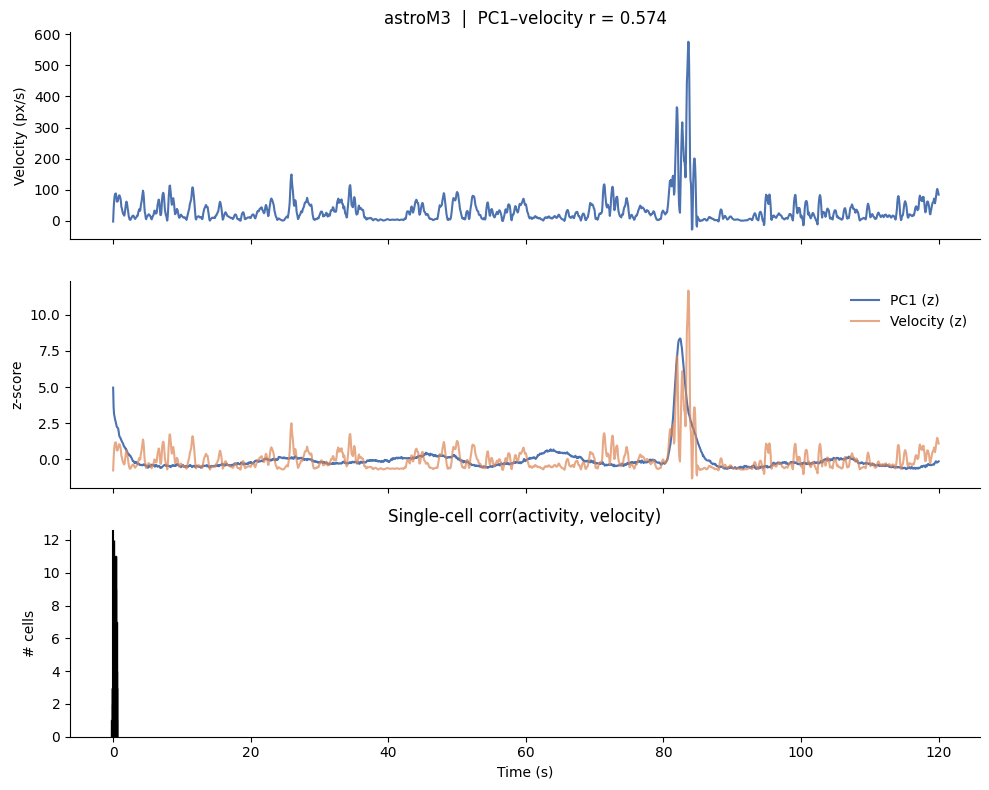

In [145]:
res = plot_mouse_summary(res, show_cell_hist=True)

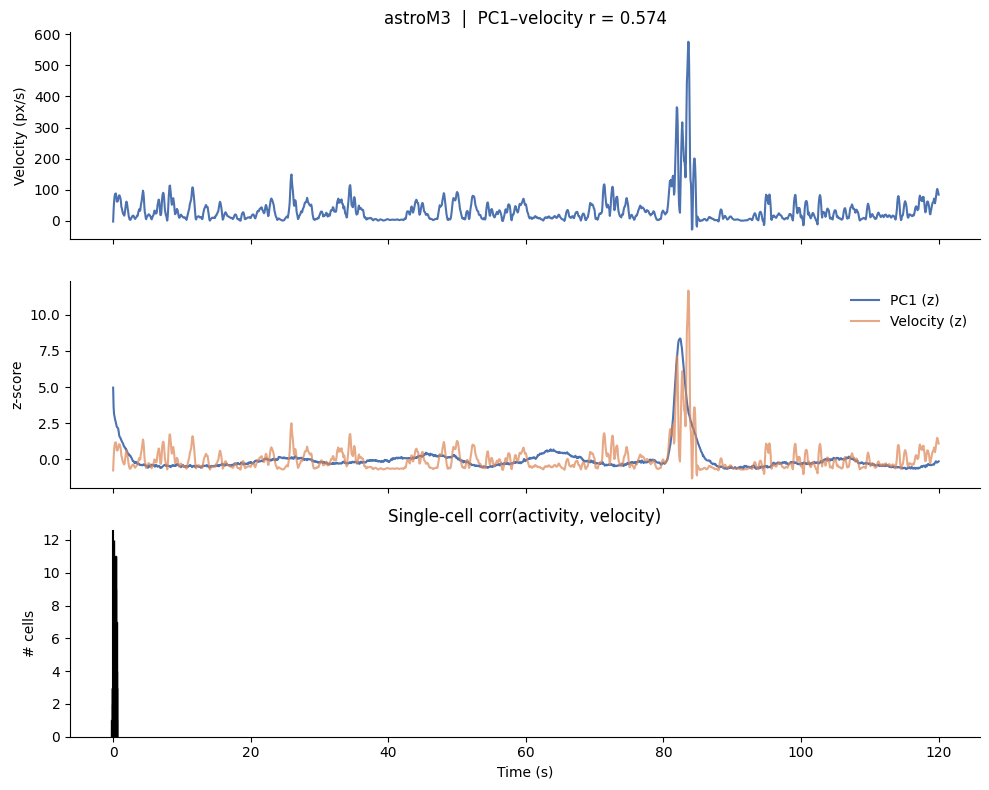

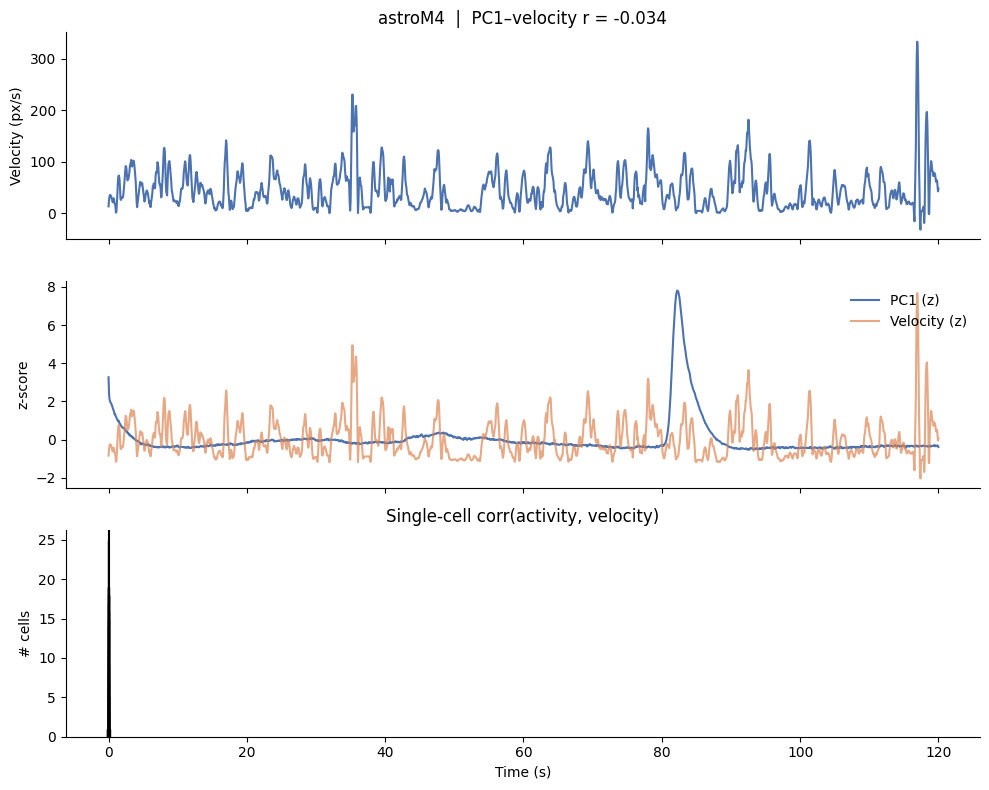

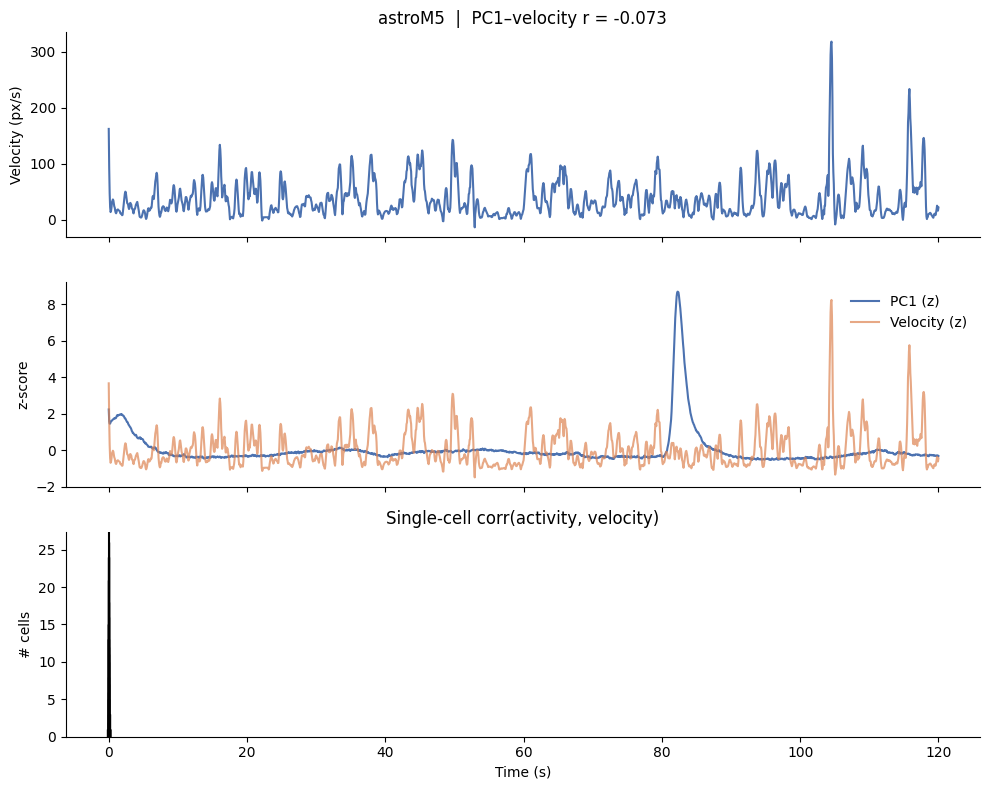

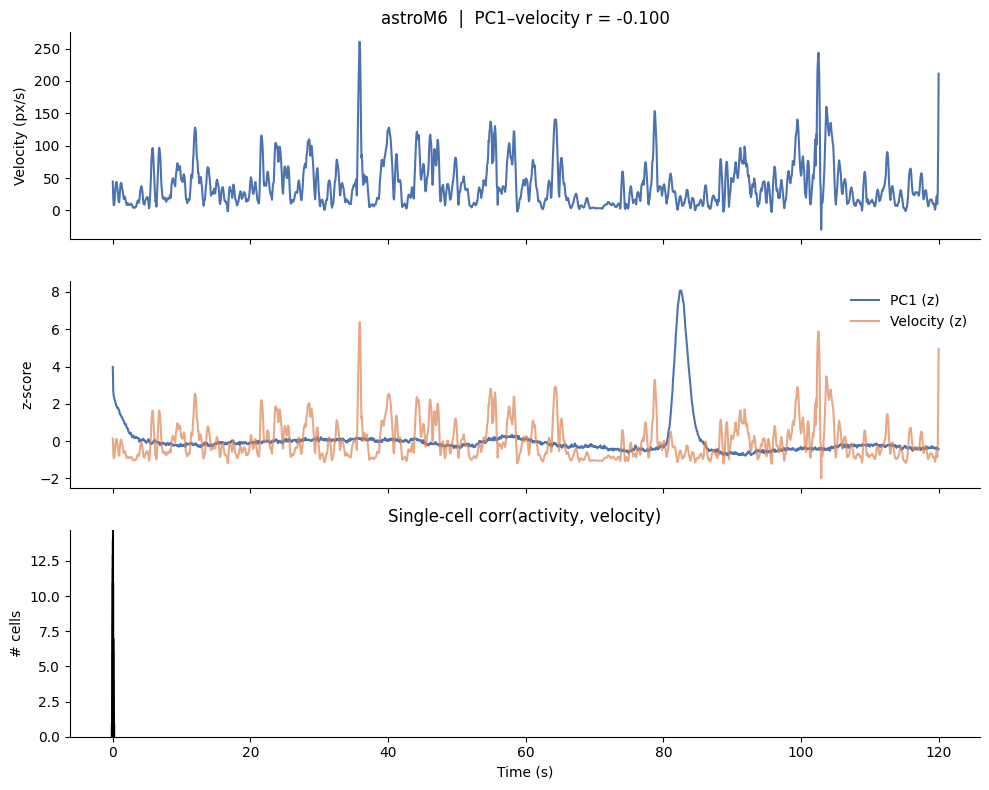

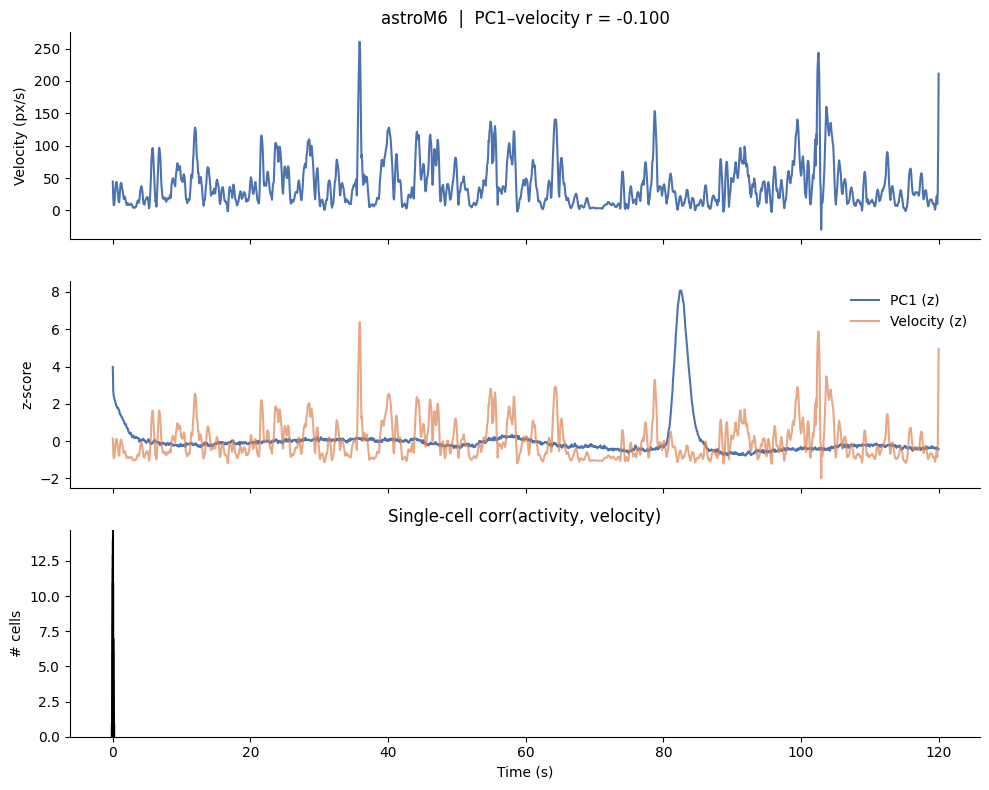

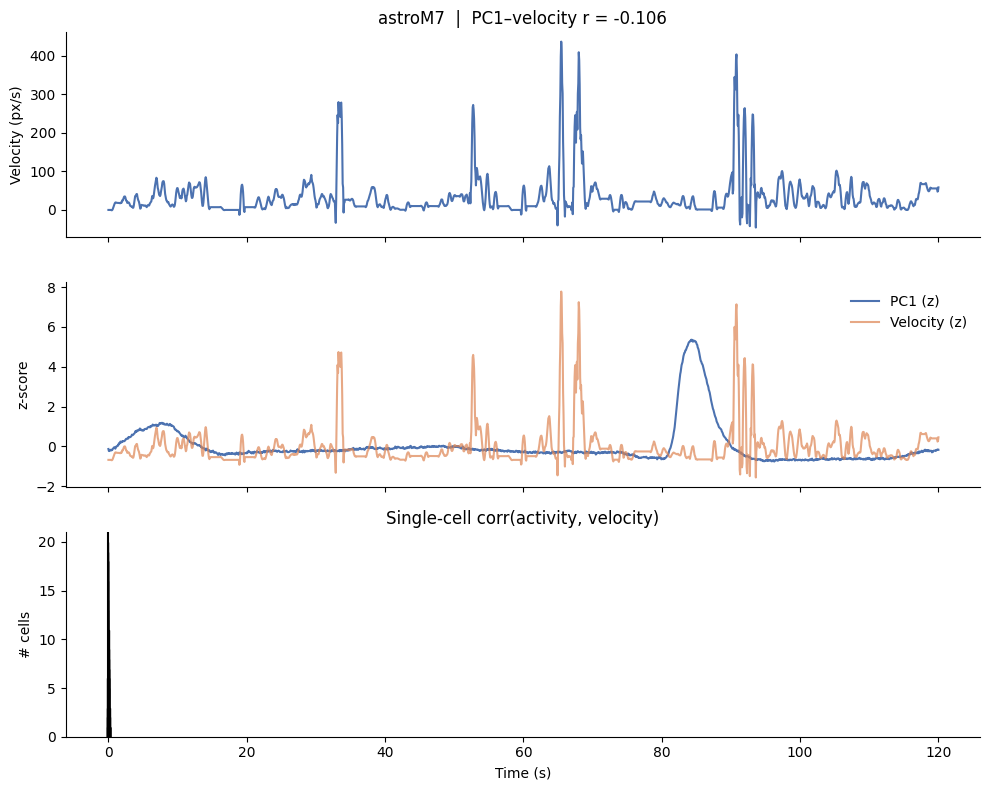

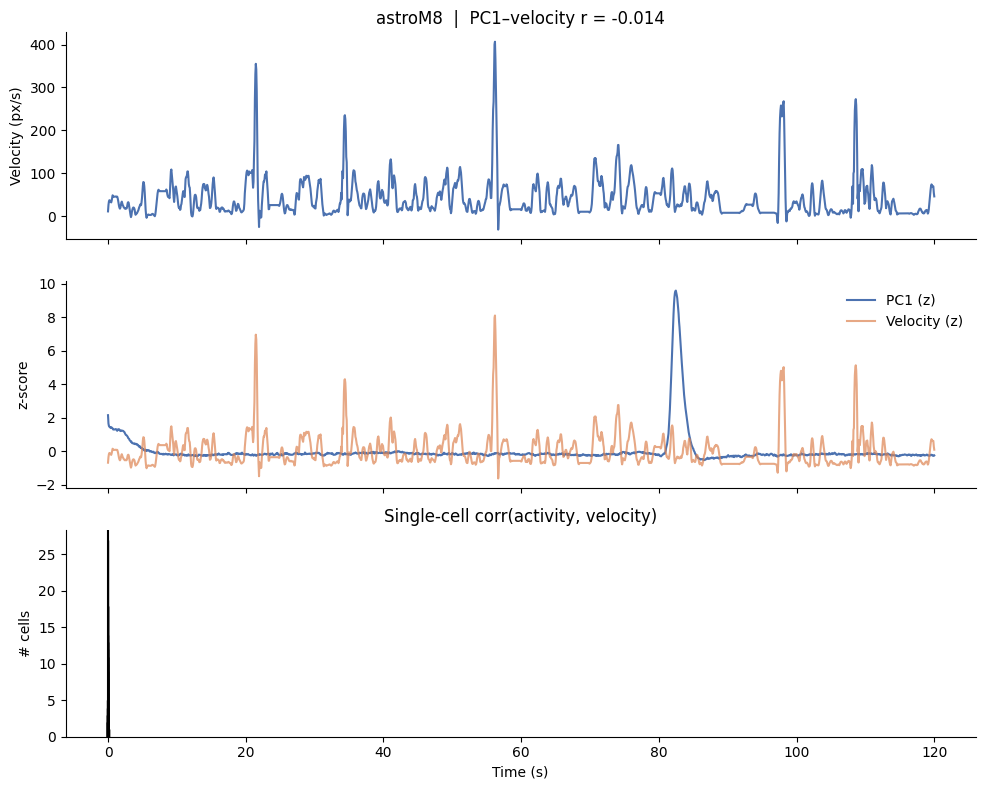

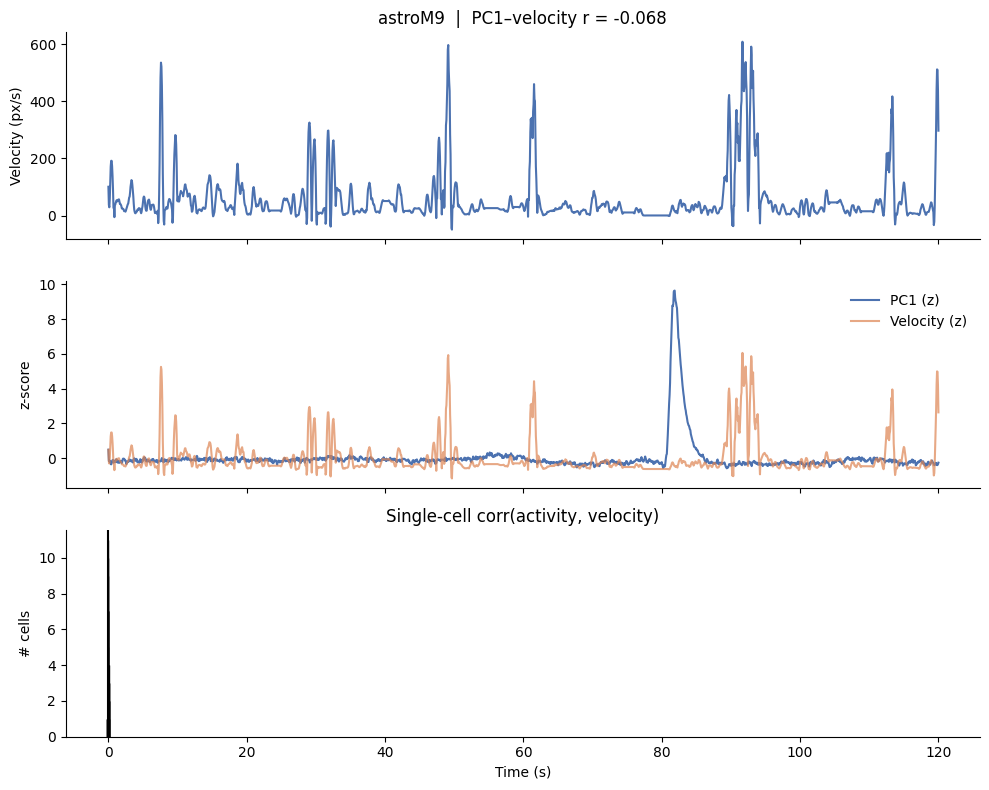

In [149]:
def find_dlc_key_for_mouse(mouse_id, dlc_data_keys):
    # mouse_id like "astroM3" -> try to match "Astro_3" or "astroM3"
    m = mouse_id.lower()
    candidates = []
    for k in dlc_data_keys:
        kl = k.lower()
        if m in kl:
            candidates.append(k)
        # also match "astro_3" style
        if "astro" in m:
            num = ''.join([c for c in m if c.isdigit()])
            if num and (f"astro_{num}" in kl or f"astro{num}" in kl):
                candidates.append(k)

    # unique preserve order
    seen = set()
    candidates = [c for c in candidates if not (c in seen or seen.add(c))]

    if len(candidates) == 0:
        raise KeyError(f"No DLC file key matched mouse_id={mouse_id}.")
    return candidates[0]  # take best match


results = {}

t_shock_1 = 120.0

for mouse_id in mouse_ids:
    # calcium
    calcium_data = globals()[mouse_id]  # (T, n_cells)

    # calcium_times: make it from FPS (or your existing calcium_times if you already have it)
    calcium_times = np.arange(calcium_data.shape[0]) / camera_fps

    # DLC df
    dlc_key = find_dlc_key_for_mouse(mouse_id, dlc_data.keys())
    dlc_df = dlc_data[dlc_key]

    res = run_mouse_velocity_pca(
        mouse_id=mouse_id,
        dlc_df=dlc_df,
        calcium_data=calcium_data,
        calcium_times=calcium_times,
        t_shock=t_shock_1,
        bodypart='tail_base',
        dlc_fps=camera_fps,
        n_pcs=10
    )

    results[mouse_id] = res

    fig = plot_mouse_summary(res, show_cell_hist=True)
    plt.show()

In [157]:
def zscore_cols(X, eps=1e-8):
    return (X - X.mean(0)) / (X.std(0) + eps)

def zscore_1d(x, eps=1e-8):
    return (x - np.mean(x)) / (np.std(x) + eps)

def circular_shift(x, min_shift=100):
    if len(x) <= 2*min_shift + 1:
        return np.roll(x, len(x)//2)
    s = np.random.randint(min_shift, len(x) - min_shift)
    return np.roll(x, s)

def pc_velocity_corr(scores, v_z):
    # correlations of each PC score with velocity
    return np.array([np.corrcoef(scores[:, k], v_z)[0, 1] for k in range(scores.shape[1])])

def velocity_subspace_score(pc_corr, var_exp):
    # variance-weighted absolute correlation
    K = min(len(pc_corr), len(var_exp))
    return float(np.sum(np.abs(pc_corr[:K]) * var_exp[:K]))

def ridge_cv_r2(X, y, alpha=1.0, n_splits=5, seed=0):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    r2s = []
    for tr, te in kf.split(X):
        m = Ridge(alpha=alpha)
        m.fit(X[tr], y[tr])
        yhat = m.predict(X[te])
        ss_res = np.sum((y[te] - yhat)**2)
        ss_tot = np.sum((y[te] - y[te].mean())**2) + 1e-12
        r2s.append(1 - ss_res/ss_tot)
    return float(np.mean(r2s))


In [153]:
def get_dlc_time(df, fps=15.0):
    # simple column
    if 'time' in df.columns:
        return df['time'].to_numpy()

    # MultiIndex time column like ('time','','')
    if isinstance(df.columns, pd.MultiIndex):
        time_cols = [c for c in df.columns if isinstance(c, tuple) and len(c) == 3 and c[0] == 'time']
        if len(time_cols) > 0:
            return df[time_cols[0]].to_numpy()

    return np.arange(len(df)) / fps


def extract_velocity_dlc(df, bodypart='tail_base', fps=15.0,
                         likelihood_thresh=0.9,
                         max_gap_frames=30,
                         smooth=True, scorer=None):

    if scorer is None:
        scorer = df.columns.get_level_values('scorer')[0]

    x = df[(scorer, bodypart, 'x')].astype(float).to_numpy()
    y = df[(scorer, bodypart, 'y')].astype(float).to_numpy()

    # mask low-confidence
    if (scorer, bodypart, 'likelihood') in df.columns:
        p = df[(scorer, bodypart, 'likelihood')].astype(float).to_numpy()
        bad = p < likelihood_thresh
        x[bad] = np.nan
        y[bad] = np.nan

    # too few points -> all nan
    if np.isfinite(x).sum() < 5 or np.isfinite(y).sum() < 5:
        return np.full_like(x, np.nan, dtype=float)

    # interpolate gaps up to max_gap_frames, then fill edges
    xs = (pd.Series(x)
          .interpolate(limit=max_gap_frames, limit_direction="both")
          .ffill().bfill())
    ys = (pd.Series(y)
          .interpolate(limit=max_gap_frames, limit_direction="both")
          .ffill().bfill())

    x = xs.to_numpy()
    y = ys.to_numpy()

    dx = np.gradient(x) * fps
    dy = np.gradient(y) * fps
    v = np.sqrt(dx**2 + dy**2)

    # clean any leftovers
    v[~np.isfinite(v)] = np.nan
    v = pd.Series(v).ffill().bfill().to_numpy()

    if smooth and len(v) >= 11:
        v = savgol_filter(v, 11, 3)

    return v


In [154]:
def analyze_mouse(
    mouse_id,
    calcium_data, 
    dlc_df,
    ca_fps=15.0,
    dlc_fps=15.0,
    t_shock=120.0,
    bodypart='tail_base',
    n_pcs=10,
    n_shuffles=300,
    likelihood_thresh=0.9
):
    # calcium time
    t_ca_full = np.arange(calcium_data.shape[0]) / ca_fps
    keep = t_ca_full <= t_shock
    t_ca = t_ca_full[keep]
    X = calcium_data[keep, :]

    # DLC velocity + time
    v = extract_velocity_dlc(dlc_df, bodypart=bodypart, fps=dlc_fps,
                             likelihood_thresh=likelihood_thresh)
    t_dlc = get_dlc_time(dlc_df, fps=dlc_fps)

    L = min(len(v), len(t_dlc))
    v = v[:L]
    t_dlc = t_dlc[:L]

    good = np.isfinite(v) & np.isfinite(t_dlc)
    if good.sum() < 10:
        raise ValueError(f"{mouse_id}: not enough finite velocity samples.")

    # interpolate velocity onto calcium time grid
    v_on_ca = np.interp(t_ca, t_dlc[good], v[good])
    v_z = zscore_1d(v_on_ca)

    # zscore calcium + PCA
    Xz = zscore_cols(X)
    pca = PCA(n_components=min(n_pcs, Xz.shape[1]))
    scores = pca.fit_transform(Xz)
    var_exp = pca.explained_variance_ratio_

    # PC correlations & subspace score
    pc_corr = pc_velocity_corr(scores, v_z)
    sub_score = velocity_subspace_score(pc_corr, var_exp)

    # shuffle null for subspace score
    null_sub = []
    for _ in range(n_shuffles):
        v_sh = circular_shift(v_z, min_shift=100)
        null_sub.append(velocity_subspace_score(pc_velocity_corr(scores, v_sh), var_exp))
    null_sub = np.array(null_sub)

    # population regression (ridge) + shuffle null
    r2_real = ridge_cv_r2(Xz, v_z, alpha=1.0, n_splits=5, seed=0)
    null_r2 = []
    for _ in range(n_shuffles):
        v_sh = circular_shift(v_z, min_shift=100)
        null_r2.append(ridge_cv_r2(Xz, v_sh, alpha=1.0, n_splits=5, seed=0))
    null_r2 = np.array(null_r2)

    # single-cell correlations
    cell_r = np.array([np.corrcoef(Xz[:, i], v_z)[0, 1] for i in range(Xz.shape[1])])

    return dict(
        mouse_id=mouse_id,
        t=t_ca,
        v=v_on_ca,
        v_z=v_z,
        Xz=Xz,
        scores=scores,
        var_exp=var_exp,
        pc_corr=pc_corr,
        sub_score=sub_score,
        null_sub=null_sub,
        r2_real=r2_real,
        null_r2=null_r2,
        cell_r=cell_r
    )

def plot_mouse_result(res, shock_time=120.0, savepath=None):
    t = res["t"]
    v = res["v"]
    v_z = res["v_z"]
    scores = res["scores"]
    pc_corr = res["pc_corr"]
    var_exp = res["var_exp"]

    sub_score = res["sub_score"]
    null_sub = res["null_sub"]
    r2_real = res["r2_real"]
    null_r2 = res["null_r2"]

    pc1_z = zscore_1d(scores[:, 0])

    fig, axes = plt.subplots(4, 1, figsize=(11, 10), sharex=False)

    # 1) velocity + PC1 over time
    ax = axes[0]
    ax.plot(t, v_z, label="velocity (z)", alpha=0.8)
    ax.plot(t, pc1_z, label="PC1 (z)", alpha=0.8)
    ax.axvline(shock_time, color="k", linestyle="--", linewidth=1)
    ax.set_ylabel("z")
    ax.set_title(f"{res['mouse_id']}")
    ax.legend(loc="upper right")

    # 2) PC correlations + variance explained
    ax = axes[1]
    xs = np.arange(1, len(pc_corr) + 1)
    ax.bar(xs, pc_corr)
    ax.axhline(0, color="k", linewidth=1)
    ax.set_ylabel("corr(PC, vel)")
    ax.set_xlabel("PC #")

    ax2 = ax.twinx()
    ax2.plot(xs, var_exp[:len(xs)], marker='o')
    ax2.set_ylabel("variance explained")

    # 3) subspace score null
    ax = axes[2]
    ax.hist(null_sub, bins=40, alpha=0.6)
    ax.axvline(sub_score, color="r", linewidth=2)
    ax.set_xlabel("Velocity subspace score = Σ |corr|×var_exp")
    ax.set_ylabel("count")
    ax.set_title(f"subspace score: {sub_score:.4f}")

    # 4) ridge R² null
    ax = axes[3]
    ax.hist(null_r2, bins=40, alpha=0.6)
    ax.axvline(r2_real, color="r", linewidth=2)
    ax.set_xlabel("Ridge CV R² predicting velocity")
    ax.set_ylabel("count")
    ax.set_title(f"ridge R²: {r2_real:.4f}")

    plt.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
        plt.close(fig)

    return fig

In [162]:
outdir = Path("velocity_analysis_figs")
outdir.mkdir(exist_ok=True)

all_results = {}

for mouse_id in mouse_ids:
    calcium_data = globals()[mouse_id]  # (3303, n_cells)

    dlc_key = find_dlc_key_for_mouse(mouse_id, dlc_data.keys())
    dlc_df = dlc_data[dlc_key]

    res = analyze_mouse(
        mouse_id=mouse_id,
        calcium_data=calcium_data,
        dlc_df=dlc_df,
        ca_fps=camera_fps,
        dlc_fps=camera_fps,
        t_shock=120.0,
        bodypart='tail_base',
        n_pcs=10,
        n_shuffles=300,
        likelihood_thresh=0.9
    )

    all_results[mouse_id] = res

    savepath = outdir / f"{mouse_id}_velocity_summary.svg"
    plot_mouse_result(res, shock_time=120.0, savepath=savepath)

print("Done. Saved figures to:", outdir.resolve())

Done. Saved figures to: C:\Users\ryansenne\PycharmProjects\dCA1_Paper\Ryan_Analyses_New\velocity_analysis_figs


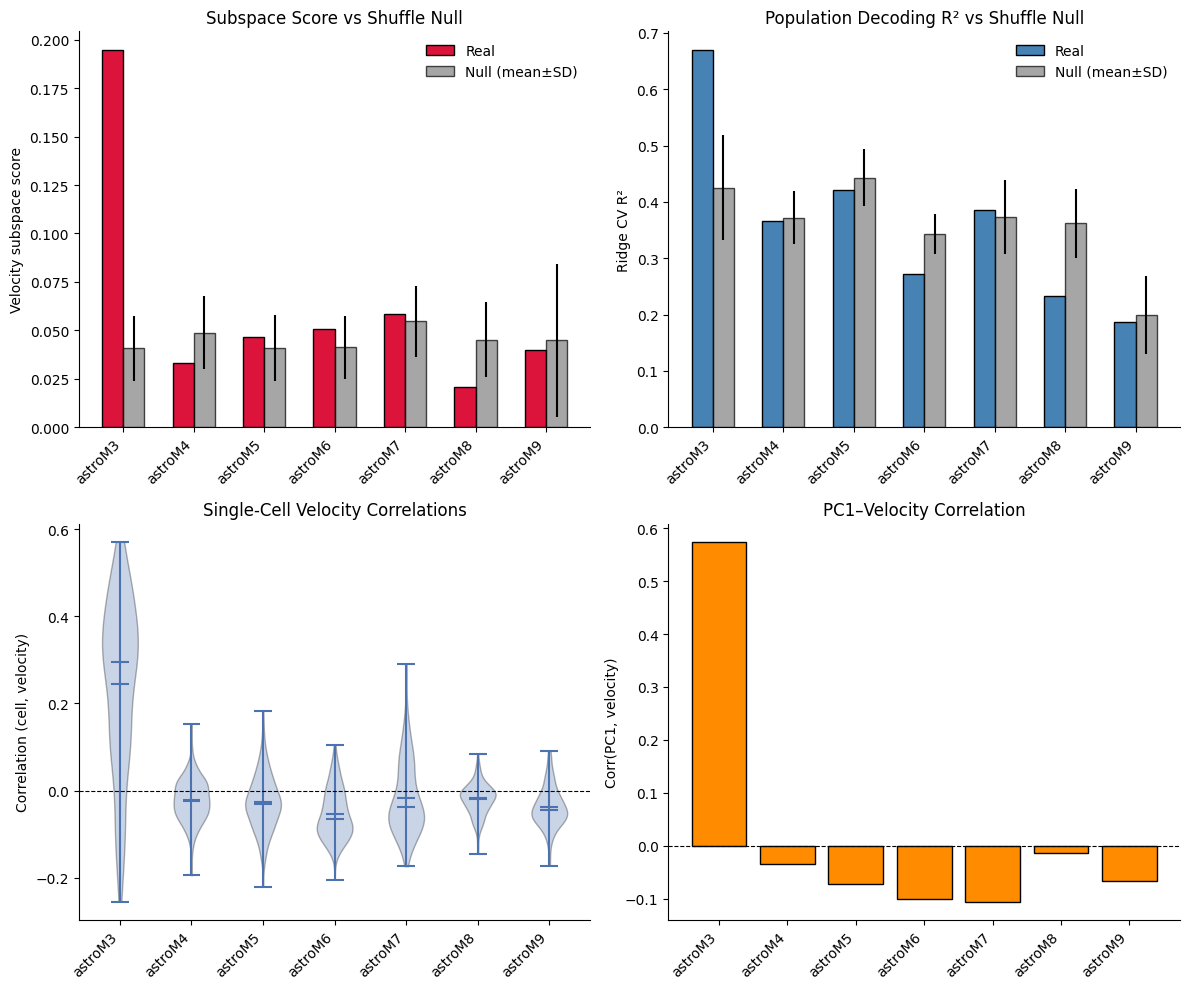

POPULATION SUMMARY

astroM3:
  Subspace score: 0.1946  (p=0.0000)
  Ridge R²:       0.6694  (p=0.0000)
  PC1 corr:       0.574
  Cell corr:      mean=0.245, median=0.296, n=165

astroM4:
  Subspace score: 0.0332  (p=0.8167)
  Ridge R²:       0.3654  (p=0.5533)
  PC1 corr:       -0.034
  Cell corr:      mean=-0.022, median=-0.023, n=275

astroM5:
  Subspace score: 0.0463  (p=0.2700)
  Ridge R²:       0.4217  (p=0.6967)
  PC1 corr:       -0.073
  Cell corr:      mean=-0.027, median=-0.030, n=288

astroM6:
  Subspace score: 0.0505  (p=0.1800)
  Ridge R²:       0.2711  (p=0.9733)
  PC1 corr:       -0.100
  Cell corr:      mean=-0.053, median=-0.065, n=177

astroM7:
  Subspace score: 0.0584  (p=0.3433)
  Ridge R²:       0.3862  (p=0.4333)
  PC1 corr:       -0.106
  Cell corr:      mean=-0.016, median=-0.038, n=253

astroM8:
  Subspace score: 0.0210  (p=0.9433)
  Ridge R²:       0.2323  (p=0.9800)
  PC1 corr:       -0.014
  Cell corr:      mean=-0.020, median=-0.017, n=239

astroM9:
  Subspa

In [ ]:
def plot_population_summary(all_results, savepath=None):
    """
    Summary plots across all mice:
    1. Subspace scores vs null (per mouse + group)
    2. Ridge R² vs null (per mouse + group)
    3. Single-cell correlation distributions
    4. PC1 correlation across mice
    """
    mouse_ids = list(all_results.keys())
    n_mice = len(mouse_ids)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Subspace score: real vs null
    ax = axes[0, 0]
    sub_scores = [all_results[m]['sub_score'] for m in mouse_ids]
    null_means = [all_results[m]['null_sub'].mean() for m in mouse_ids]
    null_stds = [all_results[m]['null_sub'].std() for m in mouse_ids]
    
    x = np.arange(n_mice)
    ax.bar(x - 0.15, sub_scores, 0.3, label='Real', color='crimson')
    ax.bar(x + 0.15, null_means, 0.3, yerr=null_stds, label='Null (mean±SD)', color='gray', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(mouse_ids, rotation=45, ha='right')
    ax.set_ylabel('Velocity subspace score')
    ax.legend()
    ax.set_title('Subspace Score vs Shuffle Null')
    
    # Ridge R²: real vs null 
    ax = axes[0, 1]
    r2_real = [all_results[m]['r2_real'] for m in mouse_ids]
    r2_null_means = [all_results[m]['null_r2'].mean() for m in mouse_ids]
    r2_null_stds = [all_results[m]['null_r2'].std() for m in mouse_ids]
    
    ax.bar(x - 0.15, r2_real, 0.3, label='Real', color='steelblue')
    ax.bar(x + 0.15, r2_null_means, 0.3, yerr=r2_null_stds, label='Null (mean±SD)', color='gray', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(mouse_ids, rotation=45, ha='right')
    ax.set_ylabel('Ridge CV R²')
    ax.legend()
    ax.set_title('Population Decoding R² vs Shuffle Null')
    
    # Single-cell correlation distributions (violin/box)
    ax = axes[1, 0]
    cell_r_all = [all_results[m]['cell_r'] for m in mouse_ids]
    parts = ax.violinplot(cell_r_all, positions=x, showmeans=True, showmedians=True)
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(mouse_ids, rotation=45, ha='right')
    ax.set_ylabel('Correlation (cell, velocity)')
    ax.set_title('Single-Cell Velocity Correlations')
    
    # PC1 correlation with velocity across mice 
    ax = axes[1, 1]
    pc1_corr = [all_results[m]['pc_corr'][0] for m in mouse_ids]  # PC1 only
    ax.bar(x, pc1_corr, color='darkorange')
    ax.axhline(0, color='k', linestyle='--', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(mouse_ids, rotation=45, ha='right')
    ax.set_ylabel('Corr(PC1, velocity)')
    ax.set_title('PC1–Velocity Correlation')
    
    plt.tight_layout()
    
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches='tight')
    
    return fig


def plot_population_stats(all_results):
    """Print summary statistics and p-values."""
    mouse_ids = list(all_results.keys())
    
    print("="*60)
    print("POPULATION SUMMARY")
    print("="*60)
    
    for m in mouse_ids:
        res = all_results[m]
        # p-value: fraction of null >= real
        p_sub = (res['null_sub'] >= res['sub_score']).mean()
        p_r2 = (res['null_r2'] >= res['r2_real']).mean()
        
        print(f"\n{m}:")
        print(f"  Subspace score: {res['sub_score']:.4f}  (p={p_sub:.4f})")
        print(f"  Ridge R²:       {res['r2_real']:.4f}  (p={p_r2:.4f})")
        print(f"  PC1 corr:       {res['pc_corr'][0]:.3f}")
        print(f"  Cell corr:      mean={res['cell_r'].mean():.3f}, "
              f"median={np.median(res['cell_r']):.3f}, "
              f"n={len(res['cell_r'])}")


# Run it
fig = plot_population_summary(all_results, savepath=outdir / "population_summary.svg")
plt.show()

plot_population_stats(all_results)